# **Step 1: Data Loading and Understanding**


In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/CC GENERAL.csv")

In [3]:
df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [6]:
df.dtypes

,0
CUST_ID,object
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64


In [7]:
df.shape

(8950, 18)

# **Step 2: Data Cleaning & Preparation**

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].mean(), inplace=True)

/tmp/ipython-input-2652015822.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].mean(), inplace=True)


In [11]:
features = [
    "BALANCE", "BALANCE_FREQUENCY", "PURCHASES", "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES", "CASH_ADVANCE", "PURCHASES_FREQUENCY",
    "CASH_ADVANCE_FREQUENCY", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS",
    "TENURE"]
X = df[features]

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaler

StandardScaler()

In [13]:
scaled_df = pd.DataFrame(X_scaled, columns=features)
scaled_df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,TENURE
count,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.949000e+03,8.950000e+03,8.950000e+03,8.950000e+03
mean,-2.540488e-17,1.587805e-16,3.175610e-18,-6.033659e-17,3.175610e-17,-6.351220e-18,9.328354e-17,-1.595744e-16,1.905579e-16,-2.540488e-17,2.699268e-17,2.921561e-16
std,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00
min,-7.516398e-01,-3.703271e+00,-4.695519e-01,-3.569340e-01,-4.545762e-01,-4.667856e-01,-1.221758e+00,-6.753489e-01,-1.221468e+00,-5.986883e-01,-3.708230e-01,-4.122768e+00
25%,-6.900078e-01,4.904486e-02,-4.510006e-01,-3.569340e-01,-4.545762e-01,-4.667856e-01,-1.014125e+00,-6.753489e-01,-7.954817e-01,-4.662913e-01,-2.975162e-01,3.606795e-01
50%,-3.320286e-01,5.180838e-01,-3.004541e-01,-3.340396e-01,-3.561562e-01,-4.667856e-01,2.404259e-02,-6.753489e-01,-4.107196e-01,-3.026846e-01,-2.268130e-01,3.606795e-01
75%,2.352559e-01,5.180838e-01,5.004652e-02,-9.056763e-03,6.366321e-02,6.435242e-02,1.062211e+00,4.351492e-01,5.511855e-01,5.802976e-02,4.878305e-17,3.606795e-01
max,8.397489e+00,5.180838e-01,2.248351e+01,2.420107e+01,2.442689e+01,2.201112e+01,1.269843e+00,6.820521e+00,7.009692e+00,1.692228e+01,3.241509e+01,3.606795e-01


# **Step 3: Exploratory Data Analysis**

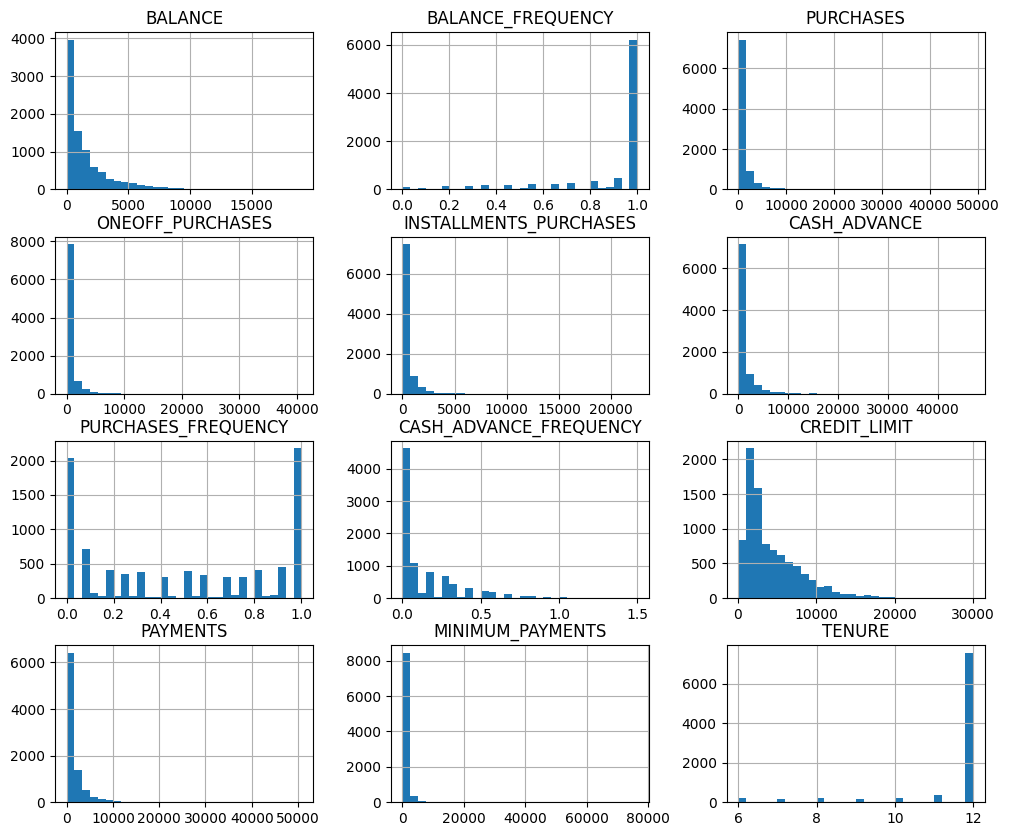

In [14]:
import matplotlib.pyplot as plt
X.hist(bins=30, figsize=(12,10))
plt.show()

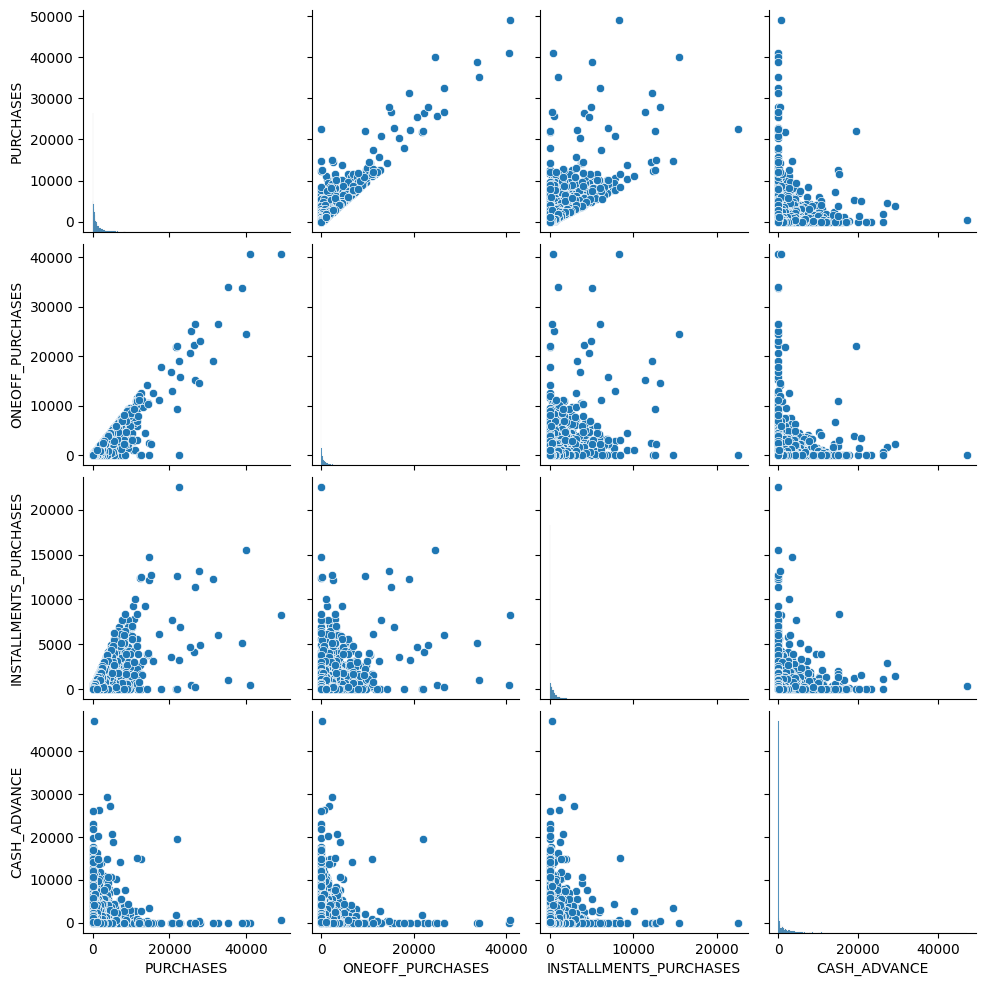

In [15]:
import seaborn as sns
sns.pairplot(df[["PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES", "CASH_ADVANCE"]])
plt.show()

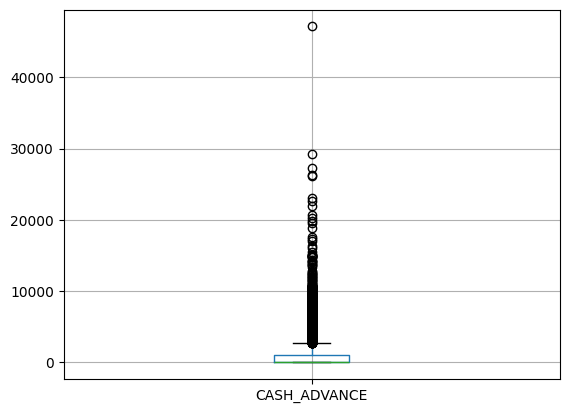

In [16]:
df.boxplot(column="CASH_ADVANCE")
plt.show()

# **Step 4: K-Means Clustering**

In [17]:
from sklearn.cluster import KMeans

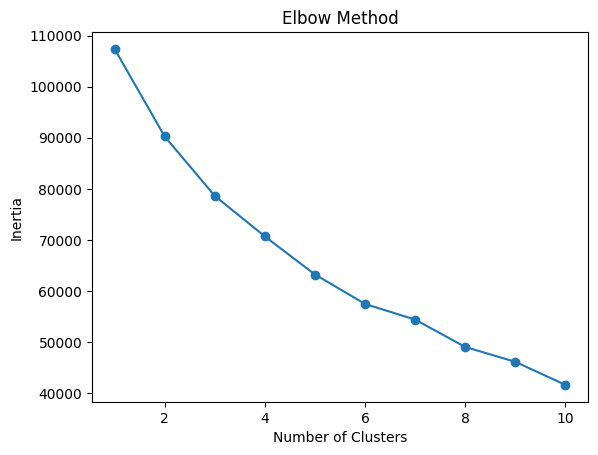

In [20]:
inertia = []
import numpy as np
credit_limit_idx = features.index('CREDIT_LIMIT')
mean_credit_limit_scaled = np.nanmean(X_scaled[:, credit_limit_idx])
X_scaled_imputed = np.nan_to_num(X_scaled, nan=mean_credit_limit_scaled)
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled_imputed) # Use the imputed data
    inertia.append(km.inertia_)
plt.figure()
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [22]:
from sklearn.metrics import silhouette_score
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto') # Added n_init to suppress future warning
    labels = km.fit_predict(X_scaled_imputed) # Use X_scaled_imputed
    score = silhouette_score(X_scaled_imputed, labels) # Use X_scaled_imputed
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.39029236606072776
K=3, Silhouette Score=0.32290534478283844
K=4, Silhouette Score=0.23697421329689353
K=5, Silhouette Score=0.22071672534644454
K=6, Silhouette Score=0.2231213406406295
K=7, Silhouette Score=0.2243824589644563
K=8, Silhouette Score=0.2296654116561337
K=9, Silhouette Score=0.2380599360652846


In [26]:
optimal_k = 2
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_optimal.fit(X_scaled_imputed)
centroids = pd.DataFrame(kmeans_optimal.cluster_centers_, columns=features)
print(centroids)

    BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  1.519697           0.405136   0.757269          0.671858   
1 -0.312126          -0.083210  -0.155533         -0.137991   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                0.556178      1.166781             0.133881   
1               -0.114232     -0.239642            -0.027497   

   CASH_ADVANCE_FREQUENCY  CREDIT_LIMIT  PAYMENTS  MINIMUM_PAYMENTS    TENURE  
0                0.951852      1.267511  1.093200          0.643364  0.127932  
1               -0.195498     -0.260330 -0.224529         -0.132139 -0.026276  


# **Step 5: Hierarchical Clustering**

In [30]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
df["H_Cluster"] = agg.fit_predict(X_scaled_imputed)

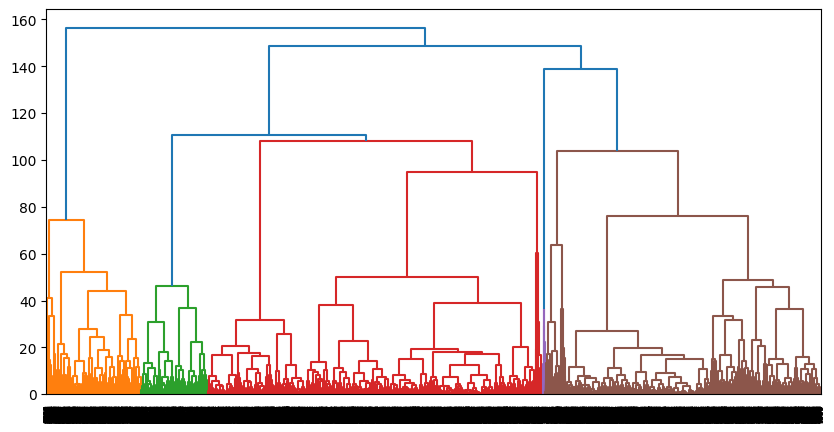

In [31]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(X_scaled_imputed, method="ward")
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.show()